In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Dropout, Sequential, ReLU, MultiheadAttention, LayerNorm, BatchNorm1d
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import GCNConv, GINEConv, global_mean_pool

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.norm2 = GraphNorm(hidden_channels)

        self.lin = Linear(hidden_channels, num_classes)
        self.dropout = Dropout(dropout)

        self.fc_out = Linear(hidden_channels, num_classes)
        self.batch_norm = BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        x = self.batch_norm(x)

        return x


class GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)
        # self.batch_norm = BatchNorm1d(hidden_channels)


    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        # x = self.batch_norm(x)

        return x


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return self.mlp(x)

class ProjectionHead_PCL(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

    def forward(self, x):
        return self.mlp(x)

class Cluster_GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, args):
        super(Cluster_GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x



In [2]:
import torch
from tqdm import tqdm
from torch_geometric.utils import subgraph
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import random
from torch_geometric.utils import to_dense_adj, dense_to_sparse
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

class Graph_Augmentation_Helper():
    def __init__(self, positive_samples, args):
        self.pos_samples = positive_samples
        self.aug_types = args.aug_types
        self.random_state = args.random_state
        self.test_size = args.test_size

        # augmentation configs
        self.shuffle_ratio = args.shuffle_ratio
        self.noise_ratio = args.noise_ratio
        self.noise_std = args.noise_std
        self.node_drop_ratio = args.node_drop_ratio
        self.edge_drop_ratio = args.edge_drop_ratio
        self.edge_add_ratio = args.edge_add_ratio
        self.alpha = args.alpha
        self.PPR_drop_ratio = args.PPR_drop_ratio
        self.PPR_add_ratio = args.PPR_add_ratio
        self.K = args.K


    def node_feature_shuffle(self, samples, shuffle_ratio):
        shuffled_samples = []
        for data in tqdm(samples, desc='Augment graph by node feature shuffling...'):
            num_features = data.x.size(1)
            num_shuffle = int(num_features * shuffle_ratio)

            perm = torch.randperm(num_features)
            shuffle_idx = perm[:num_shuffle]

            shuffled_x = data.x.clone()
            shuffled_x[:, shuffle_idx] = data.x[torch.randperm(data.x.size(0))][:, shuffle_idx]

            new_data = data.clone()
            new_data.x = shuffled_x
            new_data.id = int(str(data.id) + '000')
            shuffled_samples.append(new_data)

        return shuffled_samples
    

    def node_feature_noise_masking(self, samples, noise_ratio, noise_std):
        noise_masked_samples = []
        for data in tqdm(samples, desc='Augment graph by noise masking...'):
            x = data.x.clone()

            mask = torch.rand_like(x) < noise_ratio  

            noise = torch.randn_like(x) * noise_std
            x_noisy = x + noise * mask 

            new_data = data.clone()
            new_data.x = x_noisy
            new_data.id = int(str(data.id) + '001')
            noise_masked_samples.append(new_data)
        
        return noise_masked_samples


    def node_dropping(self, samples, drop_ratio=0.2):
        """

        """
        dropped_samples = []
        for data in tqdm(samples, desc='Augment graph by node dropping...'):
            num_nodes = data.n_nodes
            
            num_drop = max(1, int(num_nodes * drop_ratio))  # at less drop one node
            drop_nodes = torch.randperm(num_nodes)[:num_drop]
            
            keep_mask = torch.ones(num_nodes, dtype=torch.bool)
            keep_mask[drop_nodes] = False
            keep_nodes = keep_mask.nonzero(as_tuple=False).view(-1)
            
            edge_index, edge_attr = subgraph(
                subset=keep_nodes,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr if hasattr(data, "edge_attr") else None,
                relabel_nodes=True, 
                num_nodes=num_nodes
            )
            
            new_data = data.clone()
            new_data.x = data.x[keep_nodes]
            new_data.edge_index = edge_index
            new_data.edge_attr = edge_attr
            new_data.n_nodes = keep_nodes.size(0)
            new_data.id = int(str(data.id) + '010')
            dropped_samples.append(new_data)
        
        return dropped_samples
    

    def edge_perturbation_weighted(self, samples, drop_ratio, add_ratio):
        """

        """
        edge_perturbation_weighted_samples = []
        for data in tqdm(samples, desc='Augment graph by edge perturbation weighting...'):
            num_nodes = data.x.size(0)
            G = to_networkx(data, to_undirected=True)
            nodes_list = range(num_nodes)
            center_node = random.choice(nodes_list)
             
            lengths = dict(nx.single_source_shortest_path_length(G, center_node))

            max_hop = max(lengths.values()) if lengths else 0
            default_hop = max_hop + 1
            
            deg = dict(G.degree())
            
            edge_list = list(G.edges())
            edge_weights = []
            for (u, v) in edge_list:

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                hop = min(hop_u, hop_v)

                d_u = deg[u]
                d_v = deg[v]
                d = max(d_u, d_v)

                w = (1.0 / (hop + 1)) * (d / (d + 1))
                edge_weights.append(w)
 
            weights = torch.tensor(edge_weights, dtype=torch.float)
            probs = weights / weights.sum()
            

            num_drop = max(1, int(len(edge_list) * drop_ratio))
            drop_idx = torch.multinomial(probs, num_drop, replacement=False).tolist()
            drop_edges = [edge_list[i] for i in drop_idx]
            for (u,v) in drop_edges:
                if G.has_edge(u,v):
                    G.remove_edge(u, v)

            num_add = int(len(edge_list) * add_ratio)

            node_pairs = []
            attempts = 0
            while len(node_pairs) < num_add and attempts < num_add * 10:
                u = random.randrange(num_nodes)
                v = random.randrange(num_nodes)
                if u==v or G.has_edge(u,v):
                    attempts += 1
                    continue

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                if abs(hop_u - hop_v) > 0:  
                    G.add_edge(u, v)
                    node_pairs.append((u, v))
                attempts += 1
            

            new_edge_index = from_networkx(G)
            new_data = data.clone()
            new_data.x = data.x
            new_data.edge_index = new_edge_index.edge_index
            if hasattr(data, 'edge_attr'):
                new_data.edge_attr = torch.zeros((new_data.edge_index.size(1), data.edge_attr.size(1)))
            new_data.id = int(str(data.id) + '011')
            
            edge_perturbation_weighted_samples.append(new_data)

        return edge_perturbation_weighted_samples
    

    def personalized_pagerank_augmentation(self, samples, alpha, drop_ratio, add_ratio, K):
        """
        Personalized PageRank (PPR) based graph augmentation
        Args:
            data: PyG Data 对象
            alpha: teleport 概率（默认 0.15）
            drop_ratio: 删除边比例
            add_ratio: 添加边比例
        """
        PPR_samples = []

        for data in tqdm(samples, desc='Augment graph by personalized pagerank...'):
            num_nodes = data.num_nodes
            edge_index = data.edge_index

            # Step 1: 构建对称邻接矩阵
            A = to_dense_adj(edge_index, max_num_nodes=num_nodes).squeeze(0)
            A = (A + A.t()) / 2
            A.fill_diagonal_(0)

            # Step 2: 归一化邻接矩阵
            deg = A.sum(dim=1)
            deg_inv_sqrt = torch.pow(deg, -0.5)
            deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0
            D_inv_sqrt = torch.diag(deg_inv_sqrt)
            A_hat = D_inv_sqrt @ A @ D_inv_sqrt

            # Step 3: 近似计算 Personalized PageRank 矩阵
            P = torch.eye(num_nodes)
            M = torch.eye(num_nodes)
            for _ in range(K):
                M = (1 - alpha) * A_hat @ M
                P += M
            P = alpha * P

            # Step 4: 删除边
            edge_list = edge_index.t().tolist()
            edge_scores = [P[i, j].item() for i, j in edge_list]
            num_drop = int(len(edge_list) * drop_ratio)
            if num_drop > 0:
                weights = torch.tensor(edge_scores)
                weights = (weights.max() - weights + 1e-8)  # 分数越小越容易被删
                weights = weights / weights.sum()
                drop_idx = torch.multinomial(weights, num_drop, replacement=False)
                keep_edges = [edge_list[i] for i in range(len(edge_list)) if i not in drop_idx]
            else:
                keep_edges = edge_list

            # Step 5: 添加边
            adj = A.clone()
            num_add = int(len(keep_edges) * add_ratio)
            if num_add > 0:
                candidates = [(i, j) for i in range(num_nodes) for j in range(num_nodes)
                            if adj[i, j] == 0 and i != j]
                if len(candidates) > 0:
                    candidate_scores = torch.tensor([P[i, j].item() for i, j in candidates])
                    probs = candidate_scores / candidate_scores.sum()
                    add_idx = torch.multinomial(probs, min(num_add, len(candidates)), replacement=False)
                    add_edges = [candidates[i] for i in add_idx]
                    keep_edges += add_edges

            new_edge_index = torch.tensor(keep_edges).t().contiguous()

            # Step 6: 构建增强后的图
            new_data = data.clone()
            new_data.edge_index = new_edge_index
            new_data.n_edges = new_edge_index.size(1)
            new_data.edge_attr = data.edge_attr[:new_edge_index.size(1)]  # 直接截断（或重新初始化）
            new_data.id = int(str(data.id) + '100')

            PPR_samples.append(new_data)

        return PPR_samples
    

    def do_augmentation(self):
        print('Start to augment graph data')

        if self.aug_types == 'all':
            # feature-level augmentation
            node_mixup_samples = self.node_feature_shuffle(self.pos_samples, self.shuffle_ratio)
            noise_masking_samples = self.node_feature_noise_masking(self.pos_samples, self.noise_ratio, self.noise_std)
            
            # node and edge level augmentation
            node_dropping_samples = self.node_dropping(self.pos_samples, self.node_drop_ratio)
            edge_perturbation_weighted_samples = self.edge_perturbation_weighted(self.pos_samples, self.edge_drop_ratio, self.edge_add_ratio)

            # graph-level augmetation
            PPR_samples = self.personalized_pagerank_augmentation(self.pos_samples, self.alpha, self.PPR_drop_ratio, self.PPR_add_ratio, self.K)
        
        return self.pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples


    def train_test_split_positive_samples(self):
        pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples = self.do_augmentation()
        
        # split train, test set
        pos_train_set, pos_test_set = train_test_split(pos_samples, test_size=self.test_size, random_state=self.random_state)
        node_mixup_train_set, node_mixup_test_set = train_test_split(node_mixup_samples, test_size=self.test_size, random_state=self.random_state)
        noise_mask_train_set, noise_mask_test_set = train_test_split(noise_masking_samples, test_size=self.test_size, random_state=self.random_state)
        node_drop_train_set, node_drop_test_set = train_test_split(node_dropping_samples, test_size=self.test_size, random_state=self.random_state)
        edge_weight_train_set, edge_weight_test_set = train_test_split(edge_perturbation_weighted_samples, test_size=self.test_size, random_state=self.random_state)
        PPR_train_set, PPR_test_set = train_test_split(PPR_samples, test_size=self.test_size, random_state=self.random_state)

        pos_train_samples = pos_train_set + node_mixup_train_set + noise_mask_train_set + node_drop_train_set + edge_weight_train_set + PPR_train_set
        pos_test_samples = pos_test_set + node_mixup_test_set + noise_mask_test_set + node_drop_test_set + edge_weight_test_set + PPR_test_set

        return pos_train_samples, pos_test_samples


In [3]:
import torch
import argparse
import pickle
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import pandas as pd
import torch.nn.functional as F
from sklearn.metrics import silhouette_score
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


parser = argparse.ArgumentParser(description="Train a GCN model")
# unsupervised learning configs
parser = argparse.ArgumentParser(description="Train the model")
parser.add_argument('--analysis', type=bool, default=False, help='Wether to print the summary of the dataset')
parser.add_argument('--usl_batch_size', type=int, default=256, help='Batch size for training')
parser.add_argument('--num_classes', type=int, default=2, help='Number of classes')
parser.add_argument('--usl_learning_rate', type=float, default=0.0005, help='Learning rate')
parser.add_argument('--usl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--epoch', type=int, default=200, help='Number of training epochs')
parser.add_argument('--dropout', type=float, default=0.5, help='Value of dropout')
parser.add_argument('--training_types', type=str, default='Unsupervised learning', help='training_types')
parser.add_argument('--models', type=str, default='GINE', help='Training models')
parser.add_argument('--embed_dim', type=int, default=256, help='Embedding dimension of attention')
parser.add_argument('--num_heads', type=int, default=4, help='Number of heads for attention')
parser.add_argument('--desp_dim', type=int, default=217, help='Number of descriptors')
parser.add_argument('--retrain_usl', type=bool, default=False, help='retrain the usl models')
parser.add_argument('--ucl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
parser.add_argument('--save_path', type=str, default='checkpoints', help='')

# graph augmentation configs
parser.add_argument('--aug_types', type=str, default='all', help='augmentation types')
parser.add_argument('--shuffle_ratio', type=float, default=0.2, help='shuffle ratio')
parser.add_argument('--node_drop_ratio', type=float, default=0.2, help='node drop ratio')
parser.add_argument('--noise_ratio', type=float, default=0.2, help='noise_ratio')
parser.add_argument('--noise_std', type=float, default=0.1, help='noise_std')
parser.add_argument('--edge_drop_ratio', type=float, default=0.1, help='edge drop ratio')
parser.add_argument('--edge_add_ratio', type=float, default=0.05, help='edge add ratio')
parser.add_argument('--alpha', type=float, default=0.15, help='PPR alpha')
parser.add_argument('--PPR_drop_ratio', type=float, default=0.2, help='PPR_drop_ratio')
parser.add_argument('--PPR_add_ratio', type=float, default=0.2, help='PPR_add_ratio')
parser.add_argument('--K', type=int, default=10, help='PPR K')
parser.add_argument('--random_state', type=int, default=42, help='data split random seed')
parser.add_argument('--test_size', type=float, default=0.2, help='test set size')


# prototypes configs
parser.add_argument('--max_cluster', type=int, default=10, help='max cluster number')
parser.add_argument('--temperature', type=float, default=0.1, help='temperature coefficient for prototypes')
parser.add_argument('--proto_epoch', type=int, default=300, help='Number of training epochs')
parser.add_argument('--r', type=int, default=10000, help='number of randomly select neg prototypes')
parser.add_argument('--proto_training_types', type=str, default='Prototype contrastive learning', help='training_types')
parser.add_argument('--proto_models', type=str, default='GINE', help='model name for PCL')
parser.add_argument('--pcl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--pcl_learning_rate', type=float, default=0.00001, help='Learning rate')
parser.add_argument('--pcl_batch_size', type=int, default=1024, help='Batch size for training')
parser.add_argument('--threshold', type=float, default=0.3, help='threshold')
parser.add_argument('--topk', type=int, default=25, help='top k samples for each prototype')

args = parser.parse_args(args=[])
device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')


def load_data(data_path):
    # data preparation
    with open(data_path, 'rb') as f:
        all_data = pickle.load(f)

    positive_samples = all_data[:126] # number of positive samples
    unlabeled_samples = all_data[126:]

    graph_aug_helper = Graph_Augmentation_Helper(positive_samples, args)
    pos_train_samples, pos_test_samples = graph_aug_helper.train_test_split_positive_samples()
    unl_train_samples, unl_test_samples = train_test_split(unlabeled_samples, test_size=args.test_size, random_state=args.random_state)
    return positive_samples, unlabeled_samples, pos_train_samples, pos_test_samples, unl_train_samples, unl_test_samples

data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
file_path = f"/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/{args.training_types}_model_{args.models}.pth"

# load data
positive_samples_126, unlabeled_samples, pos_train_samples, pos_test_samples, unl_train_samples, unl_test_samples = load_data(data_path)

pos_loader = DataLoader(pos_train_samples + pos_test_samples, batch_size=args.pcl_batch_size, shuffle=False)
unl_loader = DataLoader(unl_train_samples + unl_test_samples, batch_size=args.pcl_batch_size, shuffle=False)

Start to augment graph data


Augment graph by personalized pagerank...: 100%|██████████| 126/126 [00:00<00:00, 146.25it/s]


In [4]:
encoder = GINE(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
        hidden_channels=args.pcl_hidden_channels,
        num_classes=args.num_classes, dropout=args.dropout, args=args).to(device)
projection = ProjectionHead_PCL(in_dim=args.pcl_hidden_channels).to(device)
encoder.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/encoder_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
projection.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/projection_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
proto_centroids = torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/proto_centroids_{args.proto_models}_epoch_{args.proto_epoch}.pth')
print('Loaded the prototype contrastive learning encoder...')


model = Cluster_GINE(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout, args=args).to(device)
model.load_state_dict(torch.load(file_path)) # load the checkpoints
projection_head = ProjectionHead(in_dim=args.usl_hidden_channels).to(device)

print(f'Loaded the unsupervised contrastive learning encoder...')


def get_embeddings(encoder, projection, dataloader, proto_centroids):
    encoder.eval()
    projection.eval()
    all_embeddings = []
    all_ids = []

    with torch.no_grad():
        for data in tqdm(dataloader):
            data = data.to(device)
            proto_centroids = proto_centroids.to(device)

            query = encoder(data.x, data.edge_index, data.edge_attr, data.batch)
            query = projection(query)
            query = F.normalize(query, dim=-1)
            all_ids.append(data.id.cpu())
            all_embeddings.append(query.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_ids = torch.cat(all_ids, dim=0)

    return all_embeddings, all_ids


emb_unl, unl_ids = get_embeddings(encoder, projection, unl_loader, proto_centroids)



Loaded the prototype contrastive learning encoder...
Loaded the unsupervised contrastive learning encoder...


100%|██████████| 176/176 [00:09<00:00, 18.34it/s]


Starting Prototype Attraction Analysis...
Embedding shape: (179825, 128)
Prototype shape: (7, 128)
Top 25% molecules: 44956
Mann-Whitney U test p-value: 0.0


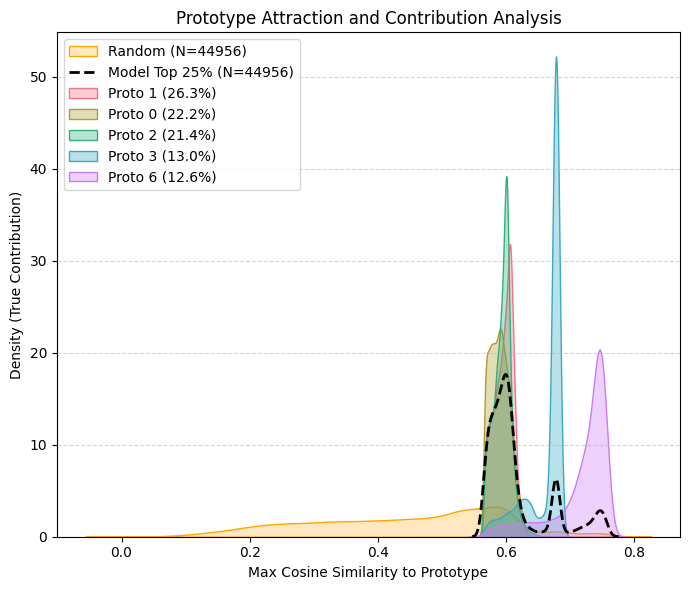

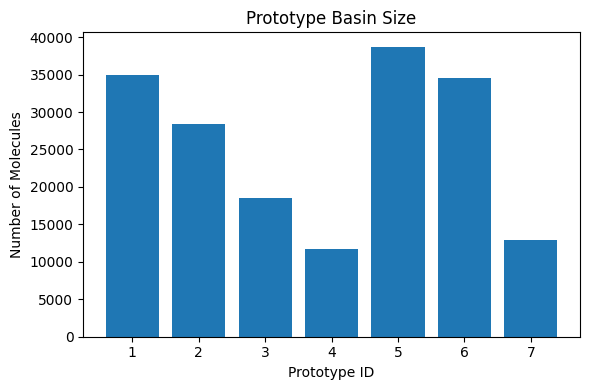

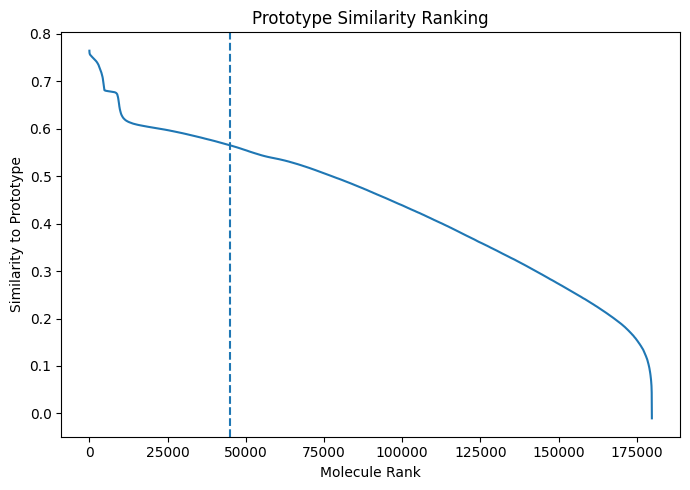

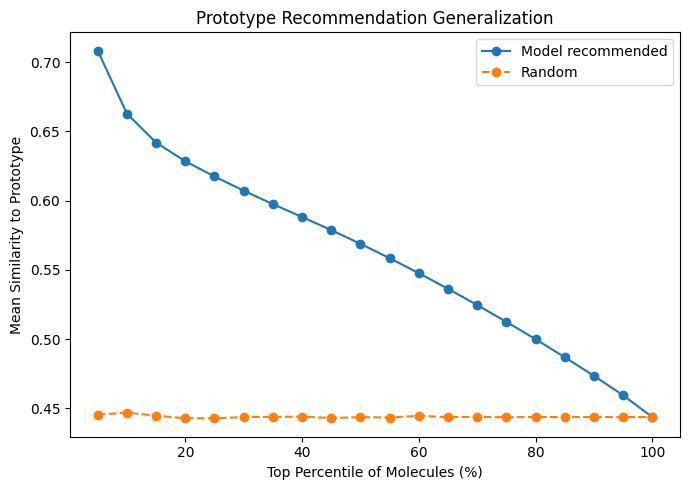

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import mannwhitneyu

print("Starting Prototype Attraction Analysis...")

# ==============================
# 1 Convert tensor to numpy
# ==============================

emb = emb_unl.numpy()
proto = proto_centroids.detach().cpu().numpy()
mol_ids = unl_ids.numpy()

print("Embedding shape:", emb.shape)
print("Prototype shape:", proto.shape)

# ==============================
# 2 Similarity matrix
# ==============================

# cosine similarity (embedding already normalized)
sim_matrix = emb @ proto.T   # [N_molecules, N_prototypes]

# closest prototype
closest_proto = np.argmax(sim_matrix, axis=1)

# similarity to closest prototype
max_sim = np.max(sim_matrix, axis=1)

# ==============================
# 3 Model recommended molecules (修改部分)
# ==============================

top_ratio = 0.25
top_n = int(len(max_sim) * top_ratio)

top_idx = np.argsort(max_sim)[-top_n:]

sim_top = max_sim[top_idx]
proto_top = closest_proto[top_idx]

print(f"Top {top_ratio*100:.0f}% molecules:", top_n)

# ==============================
# 4 Random baseline
# ==============================
random_idx = np.random.choice(len(max_sim), top_n, replace=False)
sim_random = max_sim[random_idx]

# ==============================
# 5 Statistical test
# ==============================
stat, p_value = mannwhitneyu(sim_top, sim_random)
print("Mann-Whitney U test p-value:", p_value)

# ==============================
# 6 Prototype 贡献分析
# ==============================
proto_counts = Counter(proto_top)
top_k_protos = [item[0] for item in proto_counts.most_common(5)]

# ==============================
# 7 权重（关键！！！）
# ==============================
N_total = len(max_sim)

weights_top = np.ones_like(sim_top) / N_total
weights_random = np.ones_like(sim_random) / N_total

# ==============================
# 8 Plot
# ==============================
plt.figure(figsize=(7,6))

# ===== Random =====
sns.kdeplot(
    x=sim_random,
    weights=weights_random,
    label=f"Random (N={len(sim_random)})",
    fill=True,
    color='orange',
    alpha=0.25,
    bw_adjust=1.2,
    common_norm=False
)

# ===== Model 总体 =====
sns.kdeplot(
    x=sim_top,
    weights=weights_top,
    label=f"Model Top 25% (N={len(sim_top)})",
    color='black',
    lw=2,
    linestyle='--',
    common_norm=False
)

# ===== Prototype 分解 =====
colors = sns.color_palette("husl", len(top_k_protos))

for i, p_id in enumerate(top_k_protos):
    subset_sim = sim_top[proto_top == p_id]

    count = len(subset_sim)
    percentage = count / len(sim_top) * 100

    weights_subset = np.ones_like(subset_sim) / N_total

    sns.kdeplot(
        x=subset_sim,
        weights=weights_subset,
        label=f"Proto {p_id} ({percentage:.1f}%)",
        fill=True,
        alpha=0.35,
        color=colors[i],
        common_norm=False
    )

# ==============================
# 美化
# ==============================
plt.xlabel("Max Cosine Similarity to Prototype")
plt.ylabel("Density (True Contribution)")

plt.title("Prototype Attraction and Contribution Analysis")

plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ==============================
# 🔥 导出当前图对应的KDE数据（不改原图）
# ==============================

from scipy.stats import gaussian_kde

# 和 seaborn 一致的 x 轴范围
xmin = min(max_sim)
xmax = max(max_sim)
x_grid = np.linspace(xmin, xmax, 400)

def compute_kde(x, weights, bw_adjust=1.2):
    if len(x) < 2:
        return np.zeros_like(x_grid)
    
    kde = gaussian_kde(x, weights=weights)
    kde.set_bandwidth(kde.factor * bw_adjust)  # 对齐 seaborn
    
    return kde(x_grid)

# ===== Random =====
kde_random = compute_kde(sim_random, weights_random)

# ===== Model =====
kde_model = compute_kde(sim_top, weights_top)

# ===== Prototype =====
proto_kde_dict = {}

for p_id in top_k_protos:
    subset_sim = sim_top[proto_top == p_id]
    weights_subset = np.ones_like(subset_sim) / N_total
    
    kde_vals = compute_kde(subset_sim, weights_subset)
    proto_kde_dict[p_id] = kde_vals

# ==============================
# 构建 DataFrame
# ==============================
data_dict = {
    "similarity": x_grid,
    "random": kde_random,
    "model": kde_model
}

for p_id in top_k_protos:
    data_dict[f"proto_{p_id}"] = proto_kde_dict[p_id]

df = pd.DataFrame(data_dict)

# ==============================
# 保存
# ==============================
save_path = "./plot_fig3_c.csv"
df.to_csv(save_path, index=False)


# # ==============================
# # 7 Prototype Basin Size
# # ==============================

basin_size = np.bincount(closest_proto)

plt.figure(figsize=(6,4))

plt.bar(range(1, len(basin_size)+1), basin_size)

plt.xlabel("Prototype ID")
plt.ylabel("Number of Molecules")

plt.title("Prototype Basin Size")

plt.tight_layout()

plt.show()

# ==============================
# 8 Similarity Ranking Curve
# ==============================

sorted_sim = np.sort(max_sim)[::-1]

plt.figure(figsize=(7,5))

plt.plot(sorted_sim)

plt.axvline(top_n, linestyle="--")

plt.xlabel("Molecule Rank")
plt.ylabel("Similarity to Prototype")

plt.title("Prototype Similarity Ranking")

plt.tight_layout()

plt.show()


# ==============================
# 10 Percentile Sweep Analysis
# ==============================

percentiles = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

for i in range(1, 2):

    mean_sim_model = []
    mean_sim_random = []
    for p in percentiles:

        n = int(len(max_sim) * p / 100)

        # model recommended
        idx_model = np.argsort(max_sim)[-n:]
        sim_model = max_sim[idx_model]

        # random baseline
        idx_rand = np.random.choice(len(max_sim), n, replace=False)
        sim_rand = max_sim[idx_rand]

        mean_sim_model.append(sim_model.mean())
        mean_sim_random.append(sim_rand.mean())

generalization_df = pd.DataFrame()
generalization_df['percentiles'] = percentiles
generalization_df['mean_sim_model'] = mean_sim_model
generalization_df['mean_sim_random'] = mean_sim_random
generalization_df.to_csv('./plot_fig3_b.csv', index=False)


# ==============================
# Plot Percentile Curve
# ==============================

plt.figure(figsize=(7,5))

plt.plot(percentiles, mean_sim_model, marker="o", label="Model recommended")
plt.plot(percentiles, mean_sim_random, marker="o", linestyle="--", label="Random")

plt.xlabel("Top Percentile of Molecules (%)")
plt.ylabel("Mean Similarity to Prototype")

plt.title("Prototype Recommendation Generalization")

plt.legend()

plt.tight_layout()

plt.show()

# # ==============================
# # 9 Save analysis table
# # ==============================

# df_analysis = pd.DataFrame({
#     "molecule_id": mol_ids,
#     "closest_prototype": closest_proto,
#     "similarity": max_sim
# })

# df_analysis["is_top25"] = 0
# df_analysis.loc[top_idx, "is_top25"] = 1

# # df_analysis.to_csv("prototype_attraction_analysis.csv", index=False)

prototype drift curve

Shape: (10, 299)


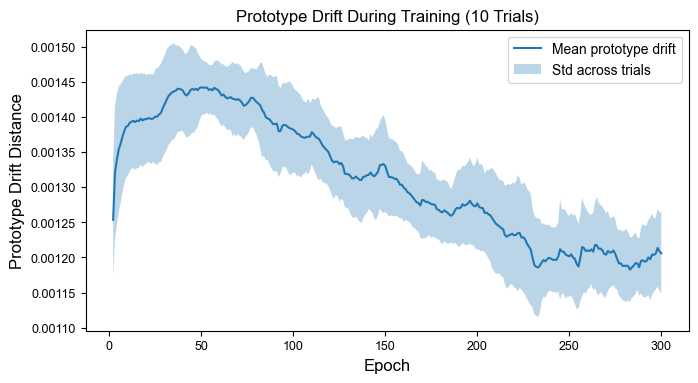

In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 可调参数
# =========================
epochs = range(1, 301)
num_trials = 10
save_path = '/data/hwx/boron/prototype_checkpoints'

# 图像尺寸（单位：cm）
width_cm = 18
height_cm = 10

# 是否保存图片
save_fig = True
fig_path = "./plot_fig3_d.svg"
dpi = 600

# =========================
# 工具函数：cm -> inch
# =========================
def cm_to_inch(cm):
    return cm / 2.54


# =========================
# 计算 drift
# =========================
all_trial_drifts = []

for trial in range(1, num_trials + 1):

    protos = []

    for e in epochs:
        p = torch.load(
            f"{save_path}/proto_trial_{trial}_epoch_{e}.pth"
        )

        p = p.detach().cpu().numpy()
        protos.append(p)

    protos = np.stack(protos)

    # compute drift
    drift = []

    for i in range(1, len(protos)):
        d = np.linalg.norm(protos[i] - protos[i - 1], axis=1)
        drift.append(d.mean())

    drift = np.array(drift)
    all_trial_drifts.append(drift)

all_trial_drifts = np.array(all_trial_drifts)

print("Shape:", all_trial_drifts.shape)


# =========================
# 统计
# =========================
mean_drift = all_trial_drifts.mean(axis=0)
std_drift = all_trial_drifts.std(axis=0)

epoch_axis = np.arange(2, 301)

# =========================
# 字体与字号设置（论文推荐）
# =========================
plt.rcParams['font.family'] = 'Arial'  # 或 'Arial'
plt.rcParams['font.size'] = 10                   # 全局默认字号
plt.rcParams['axes.labelsize'] = 12              # 坐标轴标题
plt.rcParams['xtick.labelsize'] = 9           # x刻度字号
plt.rcParams['ytick.labelsize'] = 9             # y刻度字号
plt.rcParams['legend.fontsize'] = 10             # 图例字号
plt.rcParams['axes.titlesize'] = 12              # 标题字号


# =========================
# 画图
# =========================
plt.figure(
    figsize=(cm_to_inch(width_cm), cm_to_inch(height_cm))
)

plt.plot(
    epoch_axis,
    mean_drift,
    label="Mean prototype drift"
)

plt.fill_between(
    epoch_axis,
    mean_drift - std_drift,
    mean_drift + std_drift,
    alpha=0.3,
    label="Std across trials"
)

plt.xlabel("Epoch")
plt.ylabel("Prototype Drift Distance")
plt.title("Prototype Drift During Training (10 Trials)")
# plt.xticks([])  # 去掉x轴刻度
# plt.yticks([])  # 去掉y轴刻度
plt.legend()
plt.tight_layout()

# # # 保存图片
# if save_fig:
#     plt.savefig(fig_path, dpi=dpi)

plt.show()


# =========================
# 保存数据
# =========================
df = pd.DataFrame({
    "epoch": epoch_axis,
    "mean_drift": mean_drift,
    "std_drift": std_drift
})

df.to_csv("./plot_fig3_d.csv", index=False)

(10, 300, 7, 128)
(21000, 128)


/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


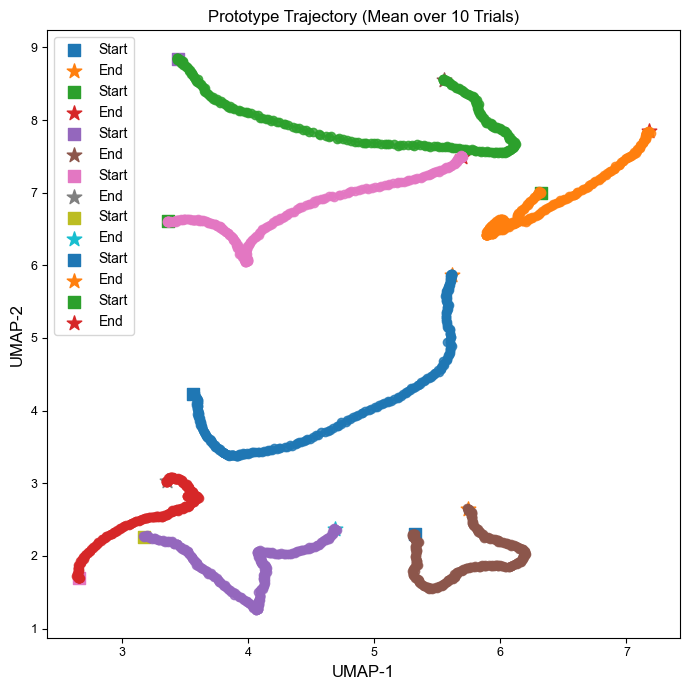

In [7]:
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

epochs = range(1,301)
num_trials = 10
save_path = '/data/hwx/boron/prototype_checkpoints'

all_trials = []

# ==============================
# 1 读取所有trial
# ==============================

for trial in range(1, num_trials+1):

    protos = []

    for e in epochs:

        p = torch.load(
            f"{save_path}/proto_trial_{trial}_epoch_{e}.pth"
        )

        p = p.detach().cpu().numpy()

        protos.append(p)

    protos = np.stack(protos)  # [epoch, proto, dim]

    all_trials.append(protos)

all_trials = np.stack(all_trials)

print(all_trials.shape)

# ==============================
# 2 flatten
# ==============================

T,E,P,D = all_trials.shape

all_proto = all_trials.reshape(-1, D)

print(all_proto.shape)

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.3,
    random_state=42
)

proto_2d = umap_model.fit_transform(all_proto)

proto_2d = proto_2d.reshape(T, E, P, 2)

mean_traj = proto_2d.mean(axis=0)
std_traj = proto_2d.std(axis=0)

plt.figure(figsize=(7,7))

for p in range(P):

    traj = mean_traj[:,p,:]

    plt.plot(
        traj[:,0],
        traj[:,1],
        marker="o",
        alpha=0.8,
    )

    plt.scatter(
        traj[0,0],
        traj[0,1],
        marker="s",
        s=80,
        label="Start"
    )

    plt.scatter(
        traj[-1,0],
        traj[-1,1],
        marker="*",
        s=120,
        label="End"
    )

plt.title("Prototype Trajectory (Mean over 10 Trials)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()


